# Preparação de dados & Exploração

## Inicialização

In [ ]:
# Carregando todas as bibliotecas
import pandas as pd
from scipy import stats as st
import numpy as np
from matplotlib import pyplot as plt


## Carregar Dados

In [ ]:
# lendo o df principal
df = pd.read_csv('data/datasets/games.csv')


## Avaliação inicial

In [ ]:
# avaliação inicial do df
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


- dataset consta de 16,715 linhas e 11 colunas
- os nomes das colunas precisam ser ajustados
- notada valores aparentemente ausentes a serem investigados
- necessita visualizar uma amostra para verificar se os tipos de dados estão coerentes
- aparentemente as colunas 2, 9 e 10 estão com os tipos de dados equivocados e precisam ser avaliados quanto a isso

In [ ]:
# visualizando uma amostra dos dados
print(df.sample(10))


                                               Name Platform  Year_of_Release  \
7840   Teenage Mutant Ninja Turtles 2: Battle Nexus       GC           2004.0   
16374                                        Dokuro      PSV           2012.0   
1994                   Jeremy McGrath Supercross 98       PS           1998.0   
10558                                      NHL 2004       GC           2003.0   
16221                   Winning Post 7 Maximum 2008      PS3           2008.0   
15242                          Rugby World Cup 2015     XOne           2015.0   
878                                Def Jam Vendetta      PS2           2003.0   
7255                                         NBA 06      PSP           2005.0   
438                                      Spider-Man       PS           2000.0   
10749                        Ben 10 Galactic Racing     X360           2011.0   

          Genre  NA_sales  EU_sales  JP_sales  Other_sales  Critic_Score  \
7840     Action      0.15      0

- 'Year_of_Release' precisa ajustar a unidade para 'int' ou 'datetime' a depender da avaliação a ser realizada.
- como melhoria: colocar unidade (milhões) nas colunas sale, max100 no critic_score e max10 no user_score
- A coluna Rating representa a Classificações etárias da ESRB com os seguintes critérios
* E — Todos
* E10+ — Idades 10 e acima
* T — 13 anos ou mais
* M — Para maiores de 17 anos
* AO — Somente para adultos
* RP — Classificação pendente 

In [ ]:
# verificando as estatísticas iniciais dos dados numéricos
df_stats = df.describe()
df_stats


,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


## Pré-processamento

#### Ajustando cabeçalho

- ajustando o formato os títulos
- incluindo informação nos títulos

In [ ]:
# verificando o título atual das colunas
print(df.columns)


Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='object')


In [ ]:
# ajustando cabeçalho com protocolo padrão de ajuste
new_col_names = []
for old_name in df.columns:
    name_stripped = old_name.strip()
    name_lowered = name_stripped.lower()
    name_no_spaces = name_lowered.replace(' ', '_')
    new_col_names.append(name_no_spaces)

df.columns = new_col_names


In [ ]:
# renomeando títulos
df = df.rename(columns={'na_sales': 'na_sales_milions',
                       'eu_sales': 'eu_sales_milions',
                       'jp_sales': 'jp_sales_milions',
                        'other_sales': 'other_sales_milions',
                       'critic_score': 'critic_score_max100',
                       'user_score': 'user_score_max10'})


In [ ]:
# verificando a modificação no título
print(df.columns)


Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales_milions',
       'eu_sales_milions', 'jp_sales_milions', 'other_sales_milions',
       'critic_score_max100', 'user_score_max10', 'rating'],
      dtype='object')


## Preparação dos dados

- avaliar dados ausentes
- avaliar dados duplicados
- ajustando tipos de dados
- calcular o total de vendas

### Avaliar dados ausentes

In [ ]:
# verificando a quantidade de dados explicitamente ausentes
print(df.isna().sum())


name                      2
platform                  0
year_of_release         269
genre                     2
na_sales_milions          0
eu_sales_milions          0
jp_sales_milions          0
other_sales_milions       0
critic_score_max100    8578
user_score_max10       6701
rating                 6766
dtype: int64


- não há valores explicitamente ausentes para as colunas sales e platform
- analisar individualmente as demais

##### Avaliar dados ausentes - coluna 'name'

In [ ]:
# avaliando a coluna 'name'
print(df[df['name'].isna()])


      name platform  year_of_release genre  na_sales_milions  \
659    NaN      GEN           1993.0   NaN              1.78   
14244  NaN      GEN           1993.0   NaN              0.00   

       eu_sales_milions  jp_sales_milions  other_sales_milions  \
659                0.53              0.00                 0.08   
14244              0.00              0.03                 0.00   

       critic_score_max100 user_score_max10 rating  
659                    NaN              NaN    NaN  
14244                  NaN              NaN    NaN  


In [ ]:
# avaliando a participação nas vendas do jogo com nome desconhecido da linha 14244
sale_14244 = df.loc[14244, 'jp_sales_milions']
total_sales_jp = df['jp_sales_milions'].sum()
print('Participação das vendas do jogo da linha 14244 é de',(sale_14244/total_sales_jp*100).round(2),'%')


Participação das vendas do jogo da linha 14244 é de 0.0 %


- linha índice 659 terá o nome substituido por 'unknown' devido a este jogo ter mais de 2 milhões em vendas.
- linha 14244 será excluída porque tem muitos dados desconhecidos e o somatório de suas vendas não tem representatividade no total.

In [ ]:
# substituindo o nome desconhecido do 'unknown' na linha 659
df.loc[659, 'name'] = 'unknown'


In [ ]:
# excluindo a linha 14244 (baixa representatividade nas vendas)
df = df.drop(index=14244).reset_index(drop=True)


In [ ]:
# confirmando o tratamento de valores ausentes na coluna 'name'
print(df[df['name'].isna()])


Empty DataFrame
Columns: [name, platform, year_of_release, genre, na_sales_milions, eu_sales_milions, jp_sales_milions, other_sales_milions, critic_score_max100, user_score_max10, rating]
Index: []


##### Avaliar dados ausentes - coluna 'year_of_release'

In [ ]:
# avaliando a coluna 'year_of_release'
print(df['year_of_release'].value_counts(dropna=False))


2008.0    1427
2009.0    1426
2010.0    1255
2007.0    1197
2011.0    1136
2006.0    1006
2005.0     939
2002.0     829
2003.0     775
2004.0     762
2012.0     653
2015.0     606
2014.0     581
2013.0     544
2016.0     502
2001.0     482
1998.0     379
2000.0     350
1999.0     338
1997.0     289
NaN        269
1996.0     263
1995.0     219
1994.0     121
1993.0      61
1981.0      46
1992.0      43
1991.0      41
1982.0      36
1986.0      21
1983.0      17
1989.0      17
1990.0      16
1987.0      16
1988.0      15
1984.0      14
1985.0      14
1980.0       9
Name: year_of_release, dtype: int64


- considerando que não há valores atípicos os valores ausentes serão removidos

In [ ]:
# substituindo os valores ausentes da coluna 'year_of_release' pela média
year_avg = df['year_of_release'].mean().round(0)
df['year_of_release'] = df['year_of_release'].fillna(year_avg)



<div class="alert alert-block alert-warning">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

Um ponto de atenção, **sem bloquear**: preencher os 269 anos ausentes com a média coloca todos esses jogos em **2007**. Isso cria um pico artificial no gráfico de lançamentos por ano e pode colocar dentro do período de análise um jogo que não pertence a ele. Como são só 1,6% das linhas, o caminho mais seguro é removê-las, ou buscar o ano do mesmo jogo em outra plataforma.
</div>

In [ ]:
# confirmando o tratamento de valores ausentes na coluna 'year_of_release'
print(df[df['year_of_release'].isna()])


Empty DataFrame
Columns: [name, platform, year_of_release, genre, na_sales_milions, eu_sales_milions, jp_sales_milions, other_sales_milions, critic_score_max100, user_score_max10, rating]
Index: []


##### Avaliar dados ausentes - coluna 'genre'

In [ ]:
# avaliando a coluna 'genre'
print(df[df['genre'].isna()])


        name platform  year_of_release genre  na_sales_milions  \
659  unknown      GEN           1993.0   NaN              1.78   

     eu_sales_milions  jp_sales_milions  other_sales_milions  \
659              0.53               0.0                 0.08   

     critic_score_max100 user_score_max10 rating  
659                  NaN              NaN    NaN  


- mesmo critério utilizado para a coluna 'name': a linha índice 659 terá o gênero substituido por 'unknown' devido a este jogo ter mais de 2 milhões em vendas.

In [ ]:
# substituindo o nome desconhecido do 'unknown' na linha 659
df.loc[659, 'genre'] = 'unknown'


In [ ]:
# confirmando o tratamento de valores ausentes na coluna 'genre'
print(df[df['genre'].isna()])


Empty DataFrame
Columns: [name, platform, year_of_release, genre, na_sales_milions, eu_sales_milions, jp_sales_milions, other_sales_milions, critic_score_max100, user_score_max10, rating]
Index: []


##### Avaliar dados ausentes - coluna 'critic_score_max100'

In [ ]:
# avaliando a coluna 'critic_score_max100'
print(df['critic_score_max100'].value_counts(dropna=False))


NaN     8577
70.0     256
71.0     254
75.0     245
78.0     240
        ... 
29.0       3
21.0       1
22.0       1
13.0       1
17.0       1
Name: critic_score_max100, Length: 83, dtype: int64


- Aproximadmente 50% dos dados desta coluna estão ausentes, então preencher com a média, a mediana ou com 0(zero) iria distorcer a análise dos dados no futuro.
- Considerando a presença de jogos antigos na amostra, ele provavelmente foram lançados anteriormente a um sistema online de agregação de pontuação crítica.
- Devido a 'gaps' na coleta e/ou agregação destes dados na fonte usada pra extrair este conjunto de dados, para esta coluna os dados permanecerão como 'NAN'.
- Caso seja necessário para alguma análise outra avaliação pode ser feita no futuro.
- Em futuras necessidade para análises gráficas estes dados podem ser filtrados

##### Avaliar dados ausentes - coluna 'user_score_max10'

In [ ]:
# avaliando os dados da coluna
print(df['user_score_max10'].value_counts(dropna=False))


NaN    6700
tbd    2424
7.8     324
8       290
8.2     282
       ... 
2.3       2
1.9       2
0.3       2
9.7       1
0         1
Name: user_score_max10, Length: 97, dtype: int64


- encontrado valores ausentes explícitos e implícitos ('tbt'), e por conter strigs e números a coluna está com o tipo de dados 'object'
- considerando que 'tbt' significa que a pontuação não estava disponível no momento da coleta da informação, ela tem a mesma representação de um valor ausente, logo trata-la como um valor ausente é mais coerente do que inserir um valor a ela, o que distorceria os dados no futuro.
- toda a coluna será convertiva como dado numérico, desta forma trantando a string 'tbt' que está influenciando na avaliação dos dados ausêntes.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

**O `tbd` foi reconhecido como ausente implícito**, e a justificativa está certa: é uma nota que ainda não existia no momento da coleta. E você manteve as notas ausentes como `NaN`, explicando que preencher com média, mediana ou zero distorceria as análises de avaliação. É a decisão certa para uma coluna com metade dos valores ausentes.
</div>

In [ ]:
# transformando os dados desta coluna em dados numéricos
df['user_score_max10'] = pd.to_numeric(df['user_score_max10'], errors='coerce')


In [ ]:
# re-avaliando os dados da coluna
print(df['user_score_max10'].value_counts(dropna=False))


NaN    9124
7.8     324
8.0     290
8.2     282
8.3     254
       ... 
1.0       2
1.5       2
9.6       2
0.0       1
9.7       1
Name: user_score_max10, Length: 96, dtype: int64


- consideranco o mesmo critério da coluna 'critic_score_max100', aproximadmente 50% dos dados desta coluna estão ausentes, então preencher com a média, a mediana ou com 0(zero) iria distorcer a análise dos dados no futuro.
- Devido a 'gaps' na coleta e/ou agregação destes dados na fonte usada pra extrair este conjunto de dados, para esta coluna os dados permanecerão como 'NAN'.
- Caso seja necessário para alguma análise outra avaliação pode ser feita no futuro.
- Em futuras necessidade para análises gráficas estes dados podem ser filtrados

#### Avaliar dados ausentes - coluna 'rating'

In [ ]:
# avaliando os dados da coluna
print(df['rating'].value_counts(dropna=False))

NaN     6765
E       3990
T       2961
M       1563
E10+    1420
EC         8
RP         3
K-A        3
AO         1
Name: rating, dtype: int64


- considerando o mesmo critério da coluna 'critic_score_max100', aproximadmente 40% dos dados desta coluna estão ausentes, então preencher com a média, a mediana ou com 0(zero) iria distorcer a análise dos dados no futuro.
- a classificação atual ESRB considera apenas as siglas E, E10+, T, M, AO e RP como critério, logo além dos dados ausentes existem dados de classificações defasada.
- Devido a 'gaps' na coleta e/ou agregação destes dados na fonte usada pra extrair este conjunto de dados, para esta coluna os dados permanecerão como 'NAN'.
- Caso seja necessário para alguma análise outra avaliação pode ser feita no futuro.
- Em futuras necessidade para análises gráficas estes dados podem ser filtrados

##### Criação de coluna baseada em 'rating' para análise futura

* criando uma nova coluna transformando os dados da coluna em numéricos

In [ ]:
# criando uma função para realizar a transformação
def esrb_code(rating):
    """
    A função retorna um código numérico para a classificação ESRB 
    usando as seguintes regras:
    — 1   para 'rating' == 'E'
    — 2   para 'rating' == 'E10+'
    — 3   para 'rating' == 'T'
    — 4   para 'rating' == 'M'
    — 5   para 'rating' == 'AO'
    — 6   para 'rating' == 'RP'
    — 7   para 'rating' == 'EC'
    — 8   para 'rating' == 'K-A'
    """
    if rating == 'E':
        return 1
    elif rating == 'E10+':
        return 2
    elif rating == 'T':
        return 3
    elif rating == 'M':
        return 4
    elif rating == 'AO':
        return 5
    elif rating == 'RP':
        return 6
    elif rating == 'EC':
        return 7
    elif rating == 'K-A':
        return 8
    else:
        return pd.NA


In [ ]:
# aplicando a função para criar a nova coluna
df['rating_code'] = df['rating'].apply(esrb_code).astype('Int64')
print(df.head())

                       name platform  year_of_release         genre  \
0                Wii Sports      Wii           2006.0        Sports   
1         Super Mario Bros.      NES           1985.0      Platform   
2            Mario Kart Wii      Wii           2008.0        Racing   
3         Wii Sports Resort      Wii           2009.0        Sports   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing   

   na_sales_milions  eu_sales_milions  jp_sales_milions  other_sales_milions  \
0             41.36             28.96              3.77                 8.45   
1             29.08              3.58              6.81                 0.77   
2             15.68             12.76              3.79                 3.29   
3             15.61             10.93              3.28                 2.95   
4             11.27              8.89             10.22                 1.00   

   critic_score_max100  user_score_max10 rating  rating_code  
0                 76.0       

* para futura análise da influência de 'rating' nas vendas, foi criada uma nova coluna numérica para o 'rating'

### Avaliar dados duplicados

In [ ]:
# contando os valores duplicados explicitamente
print('Quantidade de linha completamente duplicadas:',df.duplicated().sum())


Quantidade de linha completamente duplicadas: 0


- não há linhas completamente duplicadas

In [ ]:
# verificando valores duplicados para a coluna 'name'
print('Números de títulos únicos na coluna name:',df['name'].nunique())


Números de títulos únicos na coluna name: 11560


- como são muitos valores para confirmar gráfia única na coluna 'name', foi utilizada a estratégia de avaliar se o mesmo nome aparece mais de uma vêz.
- considerando 11560 valores únicos para 16715 linha, constata-se que exitem nomes duplicados

In [ ]:
# investigando a ocorrencia dos títulos repetido
print('LISTA COM TÍTULOS REPETIDOS NA COLUNA NAME\n',df['name'].value_counts())


LISTA COM TÍTULOS REPETIDOS NA COLUNA NAME
 Need for Speed: Most Wanted                           12
Madden NFL 07                                          9
LEGO Marvel Super Heroes                               9
FIFA 14                                                9
Ratatouille                                            9
                                                      ..
Marie no Atelier: Salburg no Renkinjutsushi            1
DriveClub                                              1
Nancy Drew: The Mystery of the Clue Bender Society     1
Kingdom of Paradise                                    1
Space Invaders Extreme 2                               1
Name: name, Length: 11560, dtype: int64


In [ ]:
# imprimindo um df filtrado com o título que mais se repete na coluna 'name'
print('LISTA COM O PRINCIPAL TÍTULO REPETIDO NA COLUNA NAME:\n',
      df[df['name']=='Need for Speed: Most Wanted'])


LISTA COM O PRINCIPAL TÍTULO REPETIDO NA COLUNA NAME:
                               name platform  year_of_release   genre  \
253    Need for Speed: Most Wanted      PS2           2005.0  Racing   
523    Need for Speed: Most Wanted      PS3           2012.0  Racing   
1190   Need for Speed: Most Wanted     X360           2012.0  Racing   
1591   Need for Speed: Most Wanted     X360           2005.0  Racing   
1998   Need for Speed: Most Wanted       XB           2005.0  Racing   
2048   Need for Speed: Most Wanted      PSV           2012.0  Racing   
3581   Need for Speed: Most Wanted       GC           2005.0  Racing   
5972   Need for Speed: Most Wanted       PC           2005.0  Racing   
6273   Need for Speed: Most Wanted     WiiU           2013.0  Racing   
6410   Need for Speed: Most Wanted       DS           2005.0  Racing   
6473   Need for Speed: Most Wanted      GBA           2005.0  Racing   
11715  Need for Speed: Most Wanted       PC           2012.0  Racing   

       n

- Constatado que não existem linhas completamente duplicadas, mas existem títulos duplicados para a coluna 'name'. Contudo, estas ocorrências referem-se a jogos com o mesmo nome que foram lançados em plataformas diferentes ou em outras circunstâncias (como em ano diferente) e não se configura como duplicados implicitamente.  

### Ajustando os tipos de dados
- coluna 2 ('year_of_release') para 'int' ou 'datetime' a depender da avaliação a ser realizada.
- aparentemente as colunas 9 e 10 estão com os tipos de dados equivocados e precisam ser avaliados quanto a isso

In [ ]:
# reavaliando a coerência dos tipos dos dados após manipulação dos mesmos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16714 entries, 0 to 16713
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 16714 non-null  object 
 1   platform             16714 non-null  object 
 2   year_of_release      16714 non-null  float64
 3   genre                16714 non-null  object 
 4   na_sales_milions     16714 non-null  float64
 5   eu_sales_milions     16714 non-null  float64
 6   jp_sales_milions     16714 non-null  float64
 7   other_sales_milions  16714 non-null  float64
 8   critic_score_max100  8137 non-null   float64
 9   user_score_max10     7590 non-null   float64
 10  rating               9949 non-null   object 
 11  rating_code          9949 non-null   Int64  
dtypes: Int64(1), float64(7), object(4)
memory usage: 1.5+ MB


- coluna 2 precisa ajustar o tipo de dado para 'int'
- colunas 9 e 10 estão com dados adequados aos seus conteúdos.

In [ ]:
# modificando os dados da coluna 2 para 'int'
df['year_of_release'] = df['year_of_release'].astype('int')


In [ ]:
# confirmando a modificação
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16714 entries, 0 to 16713
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 16714 non-null  object 
 1   platform             16714 non-null  object 
 2   year_of_release      16714 non-null  int64  
 3   genre                16714 non-null  object 
 4   na_sales_milions     16714 non-null  float64
 5   eu_sales_milions     16714 non-null  float64
 6   jp_sales_milions     16714 non-null  float64
 7   other_sales_milions  16714 non-null  float64
 8   critic_score_max100  8137 non-null   float64
 9   user_score_max10     7590 non-null   float64
 10  rating               9949 non-null   object 
 11  rating_code          9949 non-null   Int64  
dtypes: Int64(1), float64(6), int64(1), object(4)
memory usage: 1.5+ MB


- tipos de dados adequados para manipulação e análise

### Calcular o total de vendas

In [ ]:
# criando uma coluna com a soma das vendas em todas as regiões

df['total_sales_milions'] = (df['na_sales_milions'] +
                             df['eu_sales_milions'] +
                             df['jp_sales_milions'] +
                             df['other_sales_milions'])

In [ ]:
print(df.head())


                       name platform  year_of_release         genre  \
0                Wii Sports      Wii             2006        Sports   
1         Super Mario Bros.      NES             1985      Platform   
2            Mario Kart Wii      Wii             2008        Racing   
3         Wii Sports Resort      Wii             2009        Sports   
4  Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   

   na_sales_milions  eu_sales_milions  jp_sales_milions  other_sales_milions  \
0             41.36             28.96              3.77                 8.45   
1             29.08              3.58              6.81                 0.77   
2             15.68             12.76              3.79                 3.29   
3             15.61             10.93              3.28                 2.95   
4             11.27              8.89             10.22                 1.00   

   critic_score_max100  user_score_max10 rating  rating_code  \
0                 76.0      

# Analise dos dados

## Quantos jogos foram lançados a cada ano
- Os dados de cada período são significativos?

In [ ]:
# criando um df com o agrupamento da quantidade de jogos por ano
df_year = (
    df.groupby('year_of_release')['name'].count()
    .reset_index()
    .rename(columns={'name': 'quantidade'})
)
print('Planilha com a quantidade de jogos por ano\n', df_year)


Planilha com a quantidade de jogos por ano
     year_of_release  quantidade
0              1980           9
1              1981          46
2              1982          36
3              1983          17
4              1984          14
5              1985          14
6              1986          21
7              1987          16
8              1988          15
9              1989          17
10             1990          16
11             1991          41
12             1992          43
13             1993          61
14             1994         121
15             1995         219
16             1996         263
17             1997         289
18             1998         379
19             1999         338
20             2000         350
21             2001         482
22             2002         829
23             2003         775
24             2004         762
25             2005         939
26             2006        1275
27             2007        1197
28             2008        1

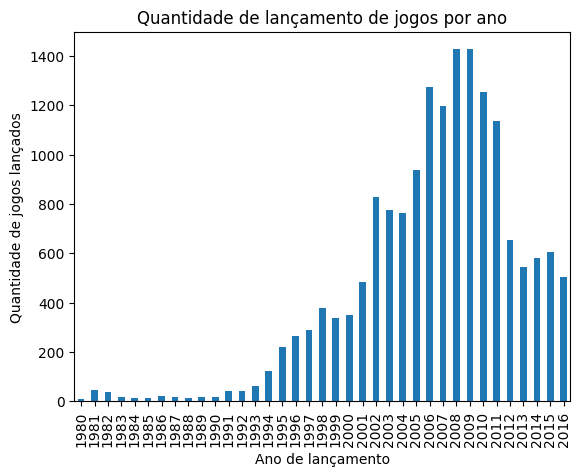

In [ ]:
# criando um gráfico com a quantidade de jogos por ano
df_year.plot(x='year_of_release', kind='bar',
            title='Quantidade de lançamento de jogos por ano',
            xlabel='Ano de lançamento',
            ylabel='Quantidade de jogos lançados',
            legend=False)
plt.show()


- existe um período inicial com poucos jogos lançados em 1980 com crescimento fraco, e a partir de 1991 acontece um movimento de crescimento dos lançamentos de jogos que se confirma em 1995, chegando a um pico por volta de 2008 e 2009. Porteriormente esse movimento de lançamento cai para um plato.

## Como as vendas variaram de plataforma para plataforma
- Escolher as plataformas com as maiores vendas totais e construa uma distribuição com base nos dados para cada ano
- Encontrar as plataformas que costumavam ser populares, mas que agora não têm vendas.
- Quanto tempo leva para as novas plataformas aparecerem e as antigas desaparecerem? 

### Plataformas com as maiores vendas totais
#### Escolhendo as plataformas

In [ ]:
# escolhendo as plataformas com as maiores vendas totais
df_p1 = (df.groupby('platform')['total_sales_milions'].sum().reset_index())

# ordenando o total de vendas
df_p1 = (
    df_p1.sort_values('total_sales_milions', ascending=False)
    .reset_index(drop=True)
)

print(df_p1)

   platform  total_sales_milions
0       PS2              1255.77
1      X360               971.42
2       PS3               939.65
3       Wii               907.51
4        DS               806.12
5        PS               730.86
6       GBA               317.85
7       PS4               314.14
8       PSP               294.05
9        PC               259.52
10      3DS               259.00
11       XB               257.74
12       GB               255.46
13      NES               251.05
14      N64               218.68
15     SNES               200.04
16       GC               198.93
17     XOne               159.32
18     2600                96.98
19     WiiU                82.19
20      PSV                54.07
21      SAT                33.59
22      GEN                30.74
23       DC                15.95
24      SCD                 1.86
25       NG                 1.44
26       WS                 1.42
27     TG16                 0.16
28      3DO                 0.10
29       G

- as plataformas selecionadas foram aquelas em que o faturamento total foi superior a pelo menos 1% da plataforma de maior faturamento.
- serão então utilizadas 24 plataformas sendo que a de menor faturamento foi a DC com 15.95 milhões.

##### Construindo uma distribuição com base nos dados para cada ano

In [ ]:
# criando um df sem as plataformas de baixo faturamento
plat_remove = ['SCD', 'NG', 'WS', 'TG16', '3DO', 'GG', 'PCFX']

df_platform = df[~df['platform'].isin(plat_remove)].reset_index(drop=True)


In [ ]:
# construindo uma distribuição com base nos dados de vendas das plataformas para cada ano
sales_year = df_platform.pivot_table(index='year_of_release',
                                   columns='platform',
                                   values='total_sales_milions',
                                   aggfunc='sum')
print(sales_year)


platform          2600    3DS    DC      DS     GB    GBA     GC    GEN  \
year_of_release                                                           
1980             11.38    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1981             35.68    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1982             28.88    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1983              5.84    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1984              0.27    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1985              0.45    NaN   NaN    0.02    NaN    NaN    NaN    NaN   
1986              0.67    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1987              1.94    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1988              0.74    NaN   NaN     NaN   1.43    NaN    NaN    NaN   
1989              0.63    NaN   NaN     NaN  64.97    NaN    NaN    NaN   
1990               NaN    NaN   NaN     NaN   4.89    NaN    NaN   2.60   
1991               NaN   

### Encontrar as plataformas que costumavam ser populares, mas que agora não têm vendas

In [ ]:
# selecionando período de vendas nos últimos 5 anos (2012-2016)
recent_years = sales_year.loc[2012:2016]

# encontrando plataformas que não tem mais vendas no período recente
platforms_no_recent_sales = recent_years.columns[recent_years.isna().all()]

# das plataformas sem vendas recentes, quais tiveram vendas expressivas em algum momento
peak_sales = (
    sales_year[platforms_no_recent_sales].max()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={0: 'total_sales_milions'})
)

print('Lista de plataformas que eram populares, mas que não vendem mais:\n',peak_sales)


Lista de plataformas que eram populares, mas que não vendem mais:
    platform  total_sales_milions
0       PS2               211.81
1        PS               169.49
2       GBA                77.91
3        XB                65.42
4        GB                64.97
5       N64                57.87
6       NES                53.44
7        GC                51.81
8      SNES                40.02
9      2600                35.68
10      GEN                12.64
11      SAT                11.57
12       DC                 5.99


### Quanto tempo leva para as novas plataformas aparecerem e as antigas desaparecerem?

In [ ]:
# criand um df com o primeiro e o último ano com vendas para cada plataforma
platform_life = pd.DataFrame({
    'first_year': sales_year.apply(lambda col: col.first_valid_index()),
    'last_year': sales_year.apply(lambda col: col.last_valid_index())
})
print(platform_life)

          first_year  last_year
platform                       
2600            1980       2006
3DS             2006       2016
DC              1998       2008
DS              1985       2013
GB              1988       2006
GBA             2000       2007
GC              2001       2007
GEN             1990       1994
N64             1996       2006
NES             1983       1994
PC              1985       2016
PS              1994       2006
PS2             2000       2011
PS3             2006       2016
PS4             2013       2016
PSP             2004       2015
PSV             2006       2016
SAT             1994       1999
SNES            1990       1999
Wii             2006       2016
WiiU            2012       2016
X360            2005       2016
XB              2000       2008
XOne            2013       2016


In [ ]:
# adicionando uma coluna com o cálculo da vida de cada plataforma
platform_life['duration_life'] = platform_life['last_year'] - platform_life['first_year']
print('Planilha com o tempo de vida das plataformas:\n\n',platform_life)


Planilha com o tempo de vida das plataformas:

           first_year  last_year  duration_life
platform                                      
2600            1980       2006             26
3DS             2006       2016             10
DC              1998       2008             10
DS              1985       2013             28
GB              1988       2006             18
GBA             2000       2007              7
GC              2001       2007              6
GEN             1990       1994              4
N64             1996       2006             10
NES             1983       1994             11
PC              1985       2016             31
PS              1994       2006             12
PS2             2000       2011             11
PS3             2006       2016             10
PS4             2013       2016              3
PSP             2004       2015             11
PSV             2006       2016             10
SAT             1994       1999              5
SNES        

In [ ]:
# Encontrando os dados estatístico do tempo de vida das plataformas
platform_life['duration_life'].describe()

count    24.000000
mean     11.166667
std       7.475564
min       3.000000
25%       6.750000
50%      10.000000
75%      11.000000
max      31.000000
Name: duration_life, dtype: float64

- o tempo de vida de uma plataforma vai de 3 a 31 anos
- o tempo médio de  vida de uma plataforma é de 11 anos

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

**O ciclo de vida das plataformas está bem calculado**, com o primeiro e o último ano de vendas de cada uma e o resumo estatístico. A média de 11 anos é a informação certa para decidir o período. O problema está no uso que vem a seguir.
</div>

## Período selecionado dos dados

* Considerando a linha do tempo apenas se poderia selecionar o período a partir de 2013 (que representa a consolidação do plato até então atual de vendas) até o ano de 2016 que representa a data mais atual.

* Desta forma é possível contemplar um período condizente com o momento da confirmação do movimento atual de lançamentos de jogos.

<div class="alert alert-block alert-danger">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

**Aqui está o motivo da devolução.** A pergunta do projeto não é "qual período cobre dois ciclos de vida", e sim **"quais dados ajudam a prever 2017"**. Um ciclo de vida longo é justamente o argumento para usar um período **curto**: em 2017 a loja vende jogos das plataformas da geração atual, e as de 1994 já saíram do mercado.

O critério usual é pegar os últimos anos em que o mercado já tem a cara atual, algo como **2013 ou 2014 em diante**, que é quando PS4 e XOne entram. A conclusão da sua própria análise de tendência (célula logo adiante) aponta para isso.

**O que refazer com o novo recorte:** as plataformas líderes, os perfis das três regiões (plataformas, gêneros e ESRB), a análise de avaliações e os dois testes. O código é todo reaproveitável: basta trocar o filtro `df['year_of_release'] >= 1994` pelo novo ano e reexecutar.

Um teste de sanidade para depois: se aparecer no top 5 de alguma região uma plataforma que não vendeu em 2016, o recorte ainda está largo demais.
</div>

<div class="alert alert-block alert-info"><b>Resposta do aluno</b> <a class="tocSkip"></a>
    
* O ano foi trocado para 2013
* a justificativa para seleção do ano foi atualizada
</div>

<div class="alert alert-block alert-success">
<b>Comentário do revisor v2 (César Malaguti):</b> <a class="tocSkip"></a>

**O recorte agora responde à pergunta certa.** 2013 é o ano em que PS4 e XOne entram, e a justificativa nova fala da consolidação do patamar atual de vendas, e não mais de cobrir ciclos de vida. E o critério para tirar plataformas irrelevantes (menos de 1% do faturamento da maior) é objetivo: só o DS, com 1,54 milhão, saiu. Um critério escrito antes de olhar o resultado é o que torna o corte defensável.
</div>

## Seleção dos dados mais relevantes

- Serão mantidos apenas os dados para o perído de 2013 a 2016
- o nome do dataframe principal será atualizado para 'df' novamente para facilitar as análises.

In [ ]:
# realizando seleção dos período de interesse conforme descrição cima
df = df[df['year_of_release'] >= 2013]


- as plataformas selecionadas foram aquelas em que o faturamento total foi superior a pelo menos 1% da plataforma de maior faturamento.


In [ ]:
# avaliando o somatório de faturamento das plataformas no período selecionado
top_platforms = (df.groupby('platform')['total_sales_milions'].sum().reset_index())

# ordenando o total de vendas
top_platforms = (
    top_platforms.sort_values('total_sales_milions', ascending=False)
    .reset_index(drop=True)
)

print('Faturamento total das plataformas de 2013 a 2016\n\n',top_platforms)


Faturamento total das plataformas de 2013 a 2016

    platform  total_sales_milions
0       PS4               314.14
1       PS3               181.43
2      XOne               159.32
3       3DS               143.25
4      X360               136.80
5      WiiU                64.63
6        PC                39.43
7       PSV                32.99
8       Wii                13.66
9       PSP                 3.50
10       DS                 1.54


In [ ]:
# criando um df sem as plataformas de baixo faturamento
plat_remove_2 = ['DS' ]

df = df[~df['platform'].isin(plat_remove_2)].reset_index(drop=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 2225 non-null   object 
 1   platform             2225 non-null   object 
 2   year_of_release      2225 non-null   int64  
 3   genre                2225 non-null   object 
 4   na_sales_milions     2225 non-null   float64
 5   eu_sales_milions     2225 non-null   float64
 6   jp_sales_milions     2225 non-null   float64
 7   other_sales_milions  2225 non-null   float64
 8   critic_score_max100  991 non-null    float64
 9   user_score_max10     1191 non-null   float64
 10  rating               1250 non-null   object 
 11  rating_code          1250 non-null   Int64  
 12  total_sales_milions  2225 non-null   float64
dtypes: Int64(1), float64(7), int64(1), object(4)
memory usage: 228.3+ KB


- 2.225 linha e 13 colunas
- dados ausentes tratados (casos específicos explicados na sessão pertinente)
- não há dados duplicados
- período de 2013 a 2016
- plataforma com menor faturamento total no perído de 3,5 milhões

<div class="alert alert-block alert-info"><b>Resposta do aluno</b> <a class="tocSkip"></a> 

* os dados de conclusão foram todos ajustados em função do novo recorte temporal
</div>

## Quais plataformas estão liderando em vendas? Quais estão crescendo ou diminuindo? Selecione várias plataformas potencialmente lucrativas.

### Quais plataformas estão liderando em vendas?

In [ ]:
# selecionando as 5 plataformas com maior faturamento
print('Plataformas líderes em vendas totais:\n', top_platforms.head(5))

Plataformas líderes em vendas totais:
   platform  total_sales_milions
0      PS4               314.14
1      PS3               181.43
2     XOne               159.32
3      3DS               143.25
4     X360               136.80


* as plataformas Top5 são: PS$, PS3, XOne, 3DS e X360 

### Quais estão crescendo ou diminuindo? 

In [ ]:
# nova distribuição de vendas (2013 a 2016)
sales_year_final = df.pivot_table(index='year_of_release',
                                 columns='platform',
                                 values='total_sales_milions',
                                 aggfunc='sum')
'''with pd.option_context('display.max_rows', None, 
                       'display.max_columns', None):'''
print(sales_year_final)


platform           3DS     PC     PS3     PS4   PSP    PSV   Wii   WiiU  \
year_of_release                                                           
2013             56.57  12.38  113.25   25.99  3.14  10.59  8.59  21.65   
2014             43.76  13.28   47.76  100.00  0.24  11.90  3.75  22.03   
2015             27.78   8.52   16.82  118.90  0.12   6.25  1.14  16.35   
2016             15.14   5.25    3.60   69.25   NaN   4.25  0.18   4.60   

platform          X360   XOne  
year_of_release                
2013             88.58  18.96  
2014             34.74  54.07  
2015             11.96  60.14  
2016              1.52  26.15  


In [ ]:
# comparando vendas médias em dois períodos recentes para avaliar tendência
period_early = sales_year_final.loc[2013:2014].mean()
period_late = sales_year_final.loc[2015:2016].mean()


In [ ]:
# criando df de tendências
trend = pd.DataFrame({
    'avg_2013_2014': period_early,
    'avg_2015_2016': period_late
})

print(trend.head())

          avg_2013_2014  avg_2015_2016
platform                              
3DS              50.165         21.460
PC               12.830          6.885
PS3              80.505         10.210
PS4              62.995         94.075
PSP               1.690          0.120


In [ ]:
# Calcaulando a variação da tendência
trend['variation_milions'] = trend['avg_2015_2016'] - trend['avg_2013_2014']


In [ ]:
# avaliando se a tendência está aumentando ou diminuindo
trend['trend'] = trend['variation_milions'].apply(
    lambda x: 'crescendo' if x > 0 else ('diminuindo' if x < 0 else 'estável')
)


In [ ]:
# ordenando por variação de tendência
trend = trend.sort_values('variation_milions', ascending=False)

print('Avaliação da tendencia de faturamento das plataformas\n\n',trend)

Avaliação da tendencia de faturamento das plataformas

           avg_2013_2014  avg_2015_2016  variation_milions       trend
platform                                                             
PS4              62.995         94.075             31.080   crescendo
XOne             36.515         43.145              6.630   crescendo
PSP               1.690          0.120             -1.570  diminuindo
Wii               6.170          0.660             -5.510  diminuindo
PC               12.830          6.885             -5.945  diminuindo
PSV              11.245          5.250             -5.995  diminuindo
WiiU             21.840         10.475            -11.365  diminuindo
3DS              50.165         21.460            -28.705  diminuindo
X360             61.660          6.740            -54.920  diminuindo
PS3              80.505         10.210            -70.295  diminuindo


- das plataformas que realmente estão faturando de 2013 a 2016, apenas PS4 e XOne estão crescendo, as demais estão com tendencia de diminuir o faturamento


<div class="alert alert-block alert-success">
<b>Comentário do revisor v2 (César Malaguti):</b> <a class="tocSkip"></a>

**A análise de tendência foi refeita dentro do recorte novo**, comparando 2013-2014 com 2015-2016, e a conclusão continua firme: só PS4 (de 63 para 94 milhões por ano) e XOne (de 36,5 para 43,1) crescem. Agora o período da análise inteira e o da tendência são o mesmo, e as duas partes contam a mesma história.
</div>

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

**Esta é a análise mais útil do notebook para a loja**, e ela já responde ao problema do período. Comparar a média de 2011-2013 com a de 2014-2016 mostra a direção de cada plataforma, e você concluiu corretamente que só PS4 e XOne crescem. É exatamente o raciocínio que faltou aplicar no recorte do resto da análise.
</div>

### Selecione várias plataformas potencialmente lucrativas

- no cenário de 2016 as plataformas potencialmente lucrativas selecionadas foram PS4 e XOne

## Construa um diagrama de caixa para as vendas globais de todos os jogos, divididos por plataforma. 

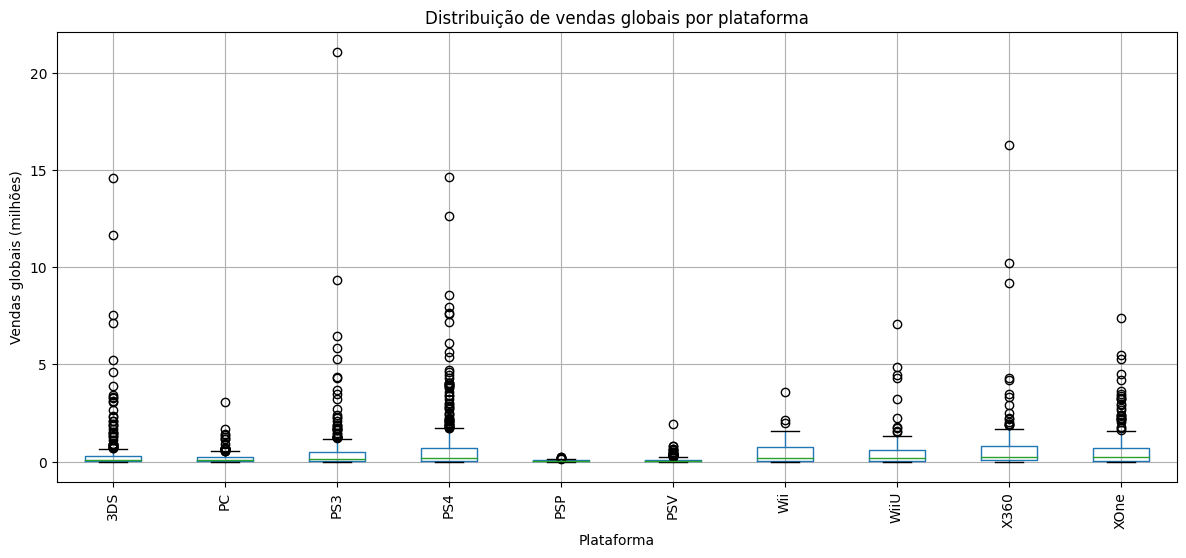

In [ ]:
# construindo um boxplot das vendas globais por plataforma
df.boxplot(column='total_sales_milions', by='platform', figsize=(14,6), rot=90)
plt.title('Distribuição de vendas globais por plataforma')
plt.suptitle('')
plt.xlabel('Plataforma')
plt.ylabel('Vendas globais (milhões)')
plt.show()


* Todas as plataformas tem muitos outliers, em função de jogos que fizeram mais sucesso do que outros
* Nesta visão um jogo em especial da plataforma Wii distorce todo o gráfico, e não é possível fazer uma análise mais detalhada das médias e das vendas. Este gráfico foi mantido para pontuar a ocorrencia destas questões.
* Uma nova plotagem será preparada com limitação no eixo Y de até 3 milhões que é a região onde a maioria dos outliers aparecem.

<div class="alert alert-block alert-warning">
<b>Comentário do revisor v2 (César Malaguti):</b> <a class="tocSkip"></a>

Este texto é do recorte antigo: **no período de 2013 em diante, o jogo que achata o gráfico não é do Wii.** O maior valor agora é o GTA V no PS3, com 21 milhões; o maior jogo do Wii no período vendeu 3,6 milhões. Troque a plataforma no texto.
</div>

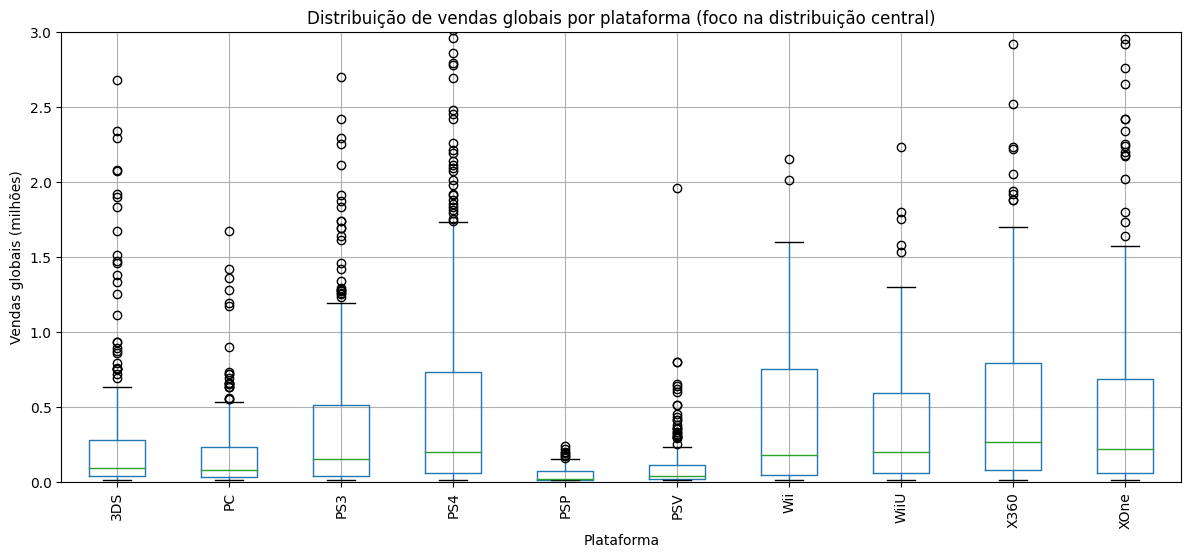

In [ ]:
# mesmo boxplot, com eixo y limitado para melhor visualização da distribuição central
df.boxplot(column='total_sales_milions', by='platform', figsize=(14,6), rot=90)
plt.title('Distribuição de vendas globais por plataforma (foco na distribuição central)')
plt.suptitle('')
plt.xlabel('Plataforma')
plt.ylabel('Vendas globais (milhões)')
plt.ylim(0, 3) 
plt.show()

In [ ]:
# estatísticas descritivas de vendas por plataforma
platform_sales_stats = df.groupby('platform')['total_sales_milions'].agg(
    ['mean', 'median', 'std', 'max', 'count']
).sort_values('mean', ascending=False)

print('Estatísticas descritivas de vendas por plataforma\n\n',platform_sales_stats)


Estatísticas descritivas de vendas por plataforma

               mean  median       std    max  count
platform                                          
PS4       0.801378   0.200  1.609456  14.63    392
X360      0.735484   0.265  1.663275  16.27    186
XOne      0.645020   0.220  1.036139   7.39    247
Wii       0.593913   0.180  0.915432   3.58     23
WiiU      0.562000   0.200  1.038778   7.09    115
PS3       0.525884   0.150  1.451939  21.05    345
3DS       0.472772   0.090  1.381347  14.60    303
PC        0.208624   0.080  0.352304   3.05    189
PSV       0.092151   0.040  0.153816   1.96    358
PSP       0.052239   0.020  0.059768   0.24     67


* é possível notar que as plataformas que são as líderes de mercado (ou foram em algum momento) além de tenderem a ter a suas médias e suas caixas mais altas, elas tem mais outliers extremos. De outro lado as plataformas com público mais específico apresetaram suas distribuições mais compactas e próximas do zero.

* analisando a diferença nas vendas através do boxplot e da estatística descritiva apresentada, é possível verificar que em sua distribuição geral, a maioria dos jogos, em qualquer plataforma, vende relativamente pouco (medianas baixas, geralmente abaixo de 0.5 milhões), enquanto uns poucos jogos "outliers" vendem dezenas de milhões. Por conta disto, o primeiro bloxpots apresentado demosntrou-se 'achatado'.


## As diferenças nas vendas são significativas? 


### Teste de Kruskal-Wallis para avaliar se a diferença nas vendas é significativa

* O teste de Kruskal-Wallis é mais adequado para este estudo, uma vez que os dados de vendas apresentam uma forte assimetria à direita, fungindo da distribuição normal.

##### Hipóteses

* $H_0$ = A diferença nas vendas tem a mesma distribuição
* $H_1$ = Pelo menos um grupo apresenta diferença na distribuição das vendas

##### Parâmetros

* alpha = 0,05


In [ ]:
# preparando os grupos de vendas por plataforma para o teste
groups = [
    group['total_sales_milions'].dropna().values
          for _, group in df.groupby('platform')
]


In [ ]:
# aplicando o teste de Kruskal-Wallis
h_stat, p_value = st.kruskal(*groups)
print(f'H estatístico: {h_stat:.2f}, p-valor: {p_value:.4f}')


H estatístico: 305.86, p-valor: 0.0000



* para saber se as diferenças nas vendas eram significativas foi aplicado o teste de Kruskal-Wallis. Nele foi constatado que o p-valor (0,0000) era menor do alpha estabelecido previamente (0,05), desta forma indicando que a diferença entre a distribuição nas plataformas é estatistivamente significante, ou seja, a distribuição de uma plataforma difere das outras.

## E quanto às vendas médias em várias plataformas? 





* Quando se compara a média e a mediana fica evidente a assimetria existente. Jogos de maior sucesso puxam a média do faturamento para cima e por conta disto a média tende a ser bem maior que a mediana em praticamente todas as plataformas. Por isso, é incorrerto analisar a venda média como métrica centrar para este projeto. A mediana é mais representativa do jogo 'típico'


## Veja como as avaliações de usuários e profissionais afetam as vendas de uma das plataformas populares (você escolhe). 

## Construa um gráfico de dispersão e calcule a correlação entre avaliações e vendas.

* escolhido o PS3 por ter um bom faturamento e uma boa quantidade de amostras.

<div class="alert alert-block alert-warning">
<b>Comentário do revisor v2 (César Malaguti):</b> <a class="tocSkip"></a>

Uma sugestão, **sem impacto na aprovação**: com o recorte novo, o PS3 é uma plataforma em queda (de 113 milhões em 2013 para 3,6 em 2016). Para uma loja que planeja 2017, a análise de avaliações e vendas diz mais se for feita no **PS4**, que lidera e cresce, e tem 392 jogos no período.
</div>

In [ ]:
# filtrar o df  para obter os dados da plataforma PS3
df_ps3 = df[df['platform'] == 'PS3'][['name', 'total_sales_milions', 
                                      'critic_score_max100', 'user_score_max10']]

print(df_ps3.info())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 345 entries, 0 to 2222
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 345 non-null    object 
 1   total_sales_milions  345 non-null    float64
 2   critic_score_max100  121 non-null    float64
 3   user_score_max10     186 non-null    float64
dtypes: float64(3), object(1)
memory usage: 13.5+ KB
None


* 345 linhas e 4 colunas
* amostra dos jogos da plataforma PS3 que foram lançados no perído de 2013 a 2016

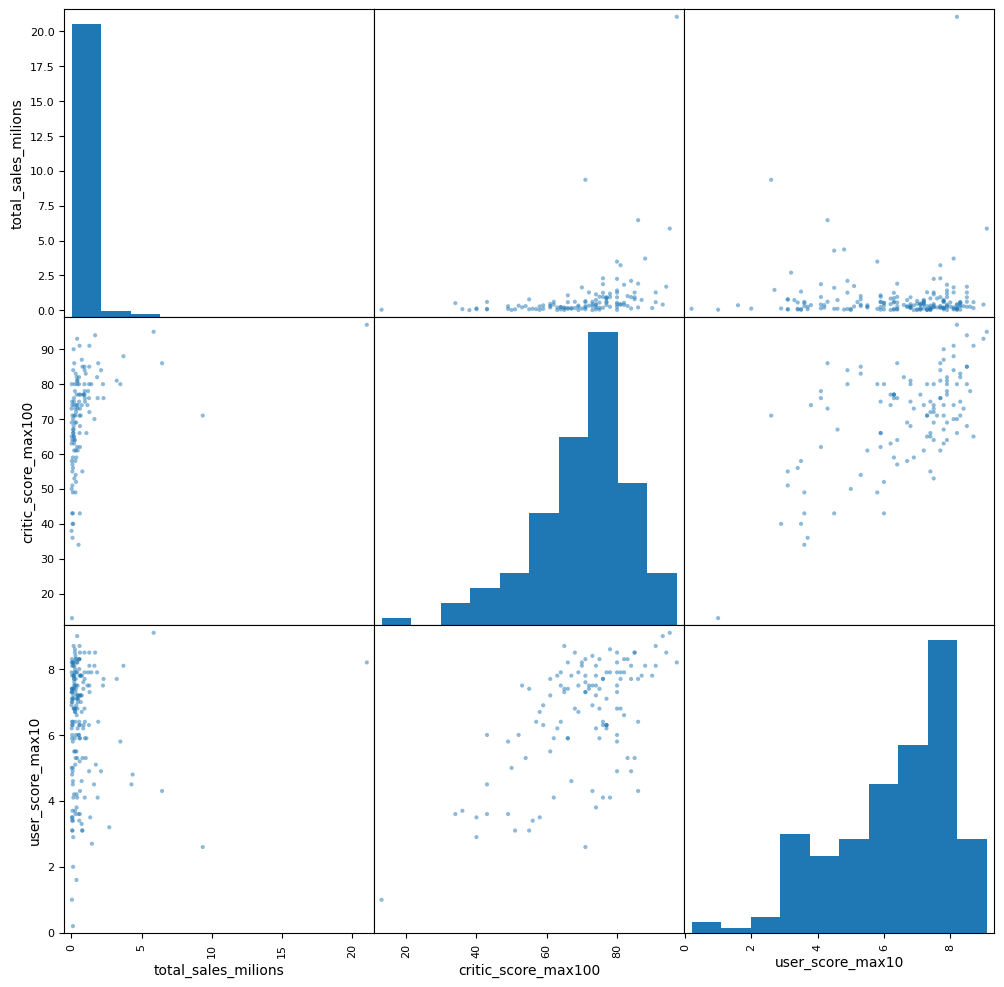

In [ ]:
# construir um gráfico de dispersão
pd.plotting.scatter_matrix(df_ps3, figsize=(12,12))
plt.show()

* analisando as vendas da plataforma PS3 em relação as avaliações de usuários e profissionais através do gráfico de dispersão é possível notar que existe uma fraca relação positiva entre as avaliações e as vendas.
* as relações entre avaliações de usuários X vendas da plataforma PS3 e avaliações profissionais X vendas na plataforma PS3 graficamente são muito parecida 

In [ ]:
# calculando a correlação entre as avaliações e as vendas
print(df_ps3.corr().round(2))

                     total_sales_milions  critic_score_max100  \
total_sales_milions                 1.00                 0.33   
critic_score_max100                 0.33                 1.00   
user_score_max10                    0.00                 0.60   

                     user_score_max10  
total_sales_milions               0.0  
critic_score_max100               0.6  
user_score_max10                  1.0  


* quando a relação entre as avaliações de usuários e as vendas da plataforma PS3 é calculada através do coeficiente de relação, é possivel verificar um valor de 0,00. Isso confirma a avaliação visual feita inicialmente através do gráfico de dispersão. Desta forma é possível inferir que as avaliações de usuários afetam muito pouco, ou em nada, as vendas da plataforma PS3.

* quando a relação entre as avaliações de profissionais e as vendas da plataformas PS3 é calculada atravé do coeficiente de relação, é possível verificar um valor de 0,33. Este dado aponta para uma correlação moderada (por estar acima de 0,3) e denota que esta relação é mais forte do que aquilo que se supos na avaliação visual através do gráfico de dispersão. Desta forma, é possível inferir que as avaliações de profissionais afetam de forma moderada as vendas na plataforma PS3.

* Possivelmente uma avaliação profissional deve ter mais peso na decisão de compra dos clientes.

## Tendo suas conclusões em mente, compare as vendas dos mesmos jogos em outras plataformas.

In [ ]:
# identificando 5 jogos que tem lançamento em mais de uma plataforma
print(df['name'].value_counts())


FIFA 14                            9
LEGO Marvel Super Heroes           8
LEGO Jurassic World                8
LEGO The Hobbit                    8
Lego Batman 3: Beyond Gotham       8
                                  ..
Dragon's Dogma Online: Season 2    1
Taishou x Alice: All in One        1
Alia's Carnival! Sacrament         1
Battle Worlds: Kronos              1
Ratchet & Clank: Into the Nexus    1
Name: name, Length: 1263, dtype: int64


In [ ]:
# criando um df com os 5 jogos selecionados
selected = ['LEGO Marvel Super Heroes', 'FIFA 14', 
            'LEGO Jurassic World', 'FIFA 15', 'Angry Birds Star Wars']
df_5 = df[df['name'].isin(selected)]
print(df_5.head())


       name platform  year_of_release   genre  na_sales_milions  \
18  FIFA 14      PS3             2013  Sports              0.78   
19  FIFA 15      PS4             2014  Sports              0.80   
38  FIFA 15      PS3             2014  Sports              0.58   
40  FIFA 14     X360             2013  Sports              0.92   
74  FIFA 14      PS4             2013  Sports              0.61   

    eu_sales_milions  jp_sales_milions  other_sales_milions  \
18              4.24              0.07                 1.37   
19              4.33              0.05                 0.90   
38              3.02              0.04                 0.64   
40              2.89              0.01                 0.40   
74              1.85              0.11                 0.44   

    critic_score_max100  user_score_max10 rating  rating_code  \
18                 86.0               4.3      E            1   
19                 82.0               5.7      E            1   
38                  NaN

In [ ]:
# criando df comparativo
df_5_pivot = df_5.pivot_table(index='name',
                             columns='platform',
                             values='total_sales_milions',
                             aggfunc='sum')
print(df_5_pivot)


platform                   3DS    PC   PS3   PS4   PSP   PSV   Wii  WiiU  \
name                                                                       
Angry Birds Star Wars     0.33   NaN  0.29  0.22   NaN  0.08  0.26  0.10   
FIFA 14                   0.23  0.40  6.46  3.01  0.19  0.41  0.38   NaN   
FIFA 15                   0.46  0.29  4.28  6.08   NaN  0.60  0.56   NaN   
LEGO Jurassic World       0.62  0.04  0.85  0.90   NaN  0.23   NaN  0.52   
LEGO Marvel Super Heroes  0.89  0.17  1.83  1.62   NaN  0.51   NaN  0.74   

platform                  X360  XOne  
name                                  
Angry Birds Star Wars     0.28  0.17  
FIFA 14                   4.22  1.16  
FIFA 15                   2.92  2.18  
LEGO Jurassic World       0.87  0.66  
LEGO Marvel Super Heroes  2.22  1.05  


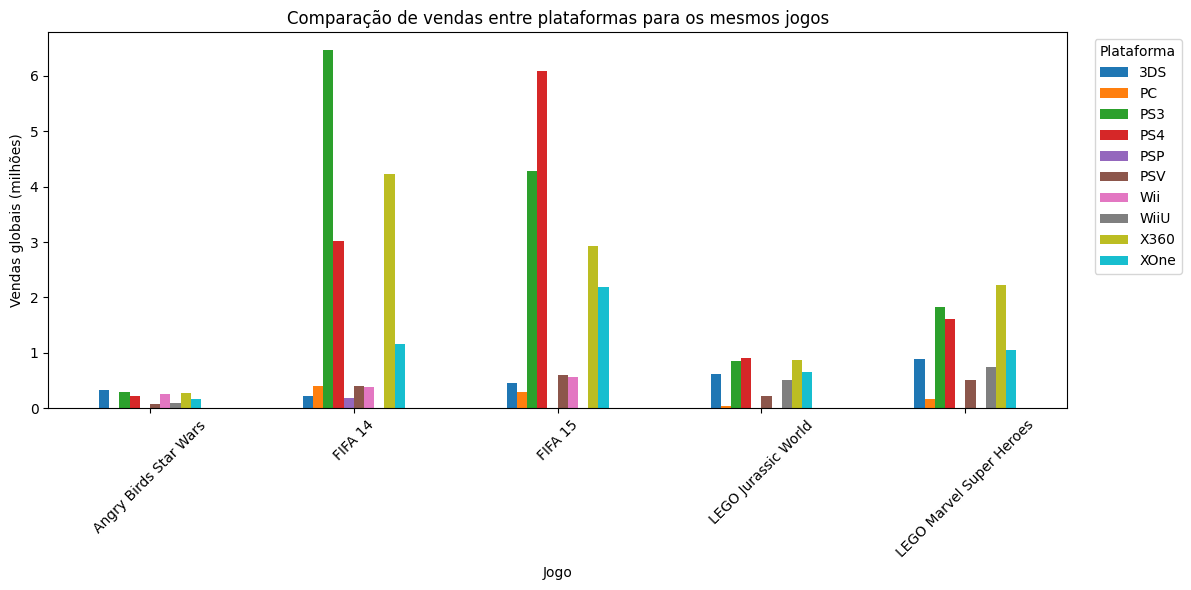

In [ ]:
 # Criando gráfico para analisar
df_5_pivot.plot(kind='bar', figsize=(12,6),
                 title='Comparação de vendas entre plataformas para os mesmos jogos',
                 xlabel='Jogo',
                 ylabel='Vendas globais (milhões)',
                 rot=45)
plt.legend(title='Plataforma', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

* apesar de se tratar do mesmo jogo, em algumas plataformas específicas o faturamento das vendas é estrondosamente maior
* por exemplo, o FIFA 14 e FIFA 15 que fizeram muito sucesso nas plataformas PS3 e PS4, mas teve um faturamento tímido na plataforma 3DS
* este gráfico ajuda a entender também uma transição de plataforma do PS3 para o PS4 com a atualizado do jogo de FIFA14 para FIFA15.

## Dê uma olhada na distribuição geral de jogos por gênero. 

## O que podemos dizer sobre os gêneros mais lucrativos? 

## Você pode generalizar sobre gêneros com vendas altas e baixas?

In [ ]:
# criando um df com agrupamento por gênero em função do total faturado
df_genre = (
    df.groupby('genre')['total_sales_milions'].sum()
    .reset_index()
).sort_values('total_sales_milions', ascending=False)

df_genre = df_genre.reset_index(drop=True)

print(df_genre)


           genre  total_sales_milions
0         Action               321.37
1        Shooter               232.98
2         Sports               150.62
3   Role-Playing               145.89
4           Misc                62.74
5       Platform                41.94
6         Racing                39.89
7       Fighting                35.31
8      Adventure                23.61
9     Simulation                21.55
10      Strategy                10.08
11        Puzzle                 3.17


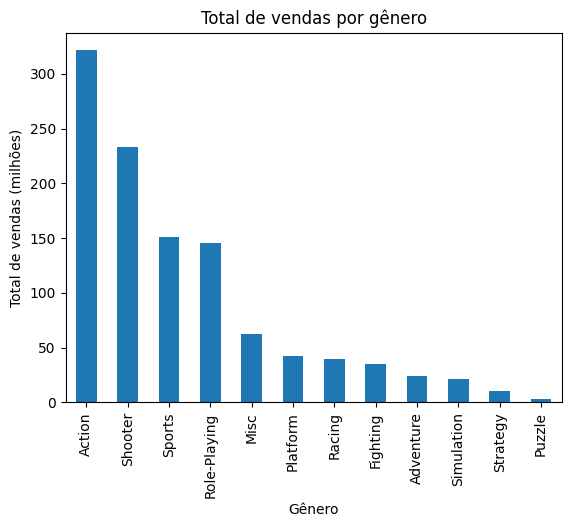

In [ ]:
df_genre.plot(x='genre', kind='bar',
             title='Total de vendas por gênero',
             xlabel='Gênero', 
             ylabel='Total de vendas (milhões)',
             legend=False)
plt.show()


* de uma forma geral, os jogos de esporte e ação foram aqueles que geraram maior faturamento, seguidos por aqueles de tiro, RPG.
* considerando que os jogos de estratégia e quebra-cabeça são os jogos de menor faturamento, poderia-se generalizar sobre a alta e baixa dos gêneros quanto a ação que eles proporcionam ou geram.
* Contudo levando-se em conta que dois gêneros de jogos que exigem concentraçao (de tiro e de RPG) ficaram em terceiro e quarto lugar de faturamento, talvez fosse interessante investigar mais a fundo sobre estes dois gêneros em questão antes de confirmar essa generalização.

# Crie um perfil de usuário para cada região

## Região NA

### As cinco plataformas principais. 

#### Descreva as variações das suas quotas de mercado.

In [ ]:
# levantando dados sobre o faturamento das plataformas na região
na_plat = (
    df.groupby('platform')['na_sales_milions'].sum().reset_index()
    .sort_values('na_sales_milions', ascending=False)
)
na_plat = na_plat.reset_index(drop=True)
print(na_plat.head(5))


  platform  na_sales_milions
0      PS4            108.74
1     XOne             93.12
2     X360             81.66
3      PS3             63.50
4      3DS             38.20


In [ ]:
# obtendo o percentual de suas cotas de participação na região 
na_plat['participation_%'] = (na_plat['na_sales_milions'] / na_plat['na_sales_milions'].sum()*100).round(2)

print(na_plat)


  platform  na_sales_milions  participation_%
0      PS4            108.74            24.88
1     XOne             93.12            21.30
2     X360             81.66            18.68
3      PS3             63.50            14.53
4      3DS             38.20             8.74
5     WiiU             29.21             6.68
6       PC             11.11             2.54
7      Wii              6.56             1.50
8      PSV              5.04             1.15
9      PSP              0.00             0.00


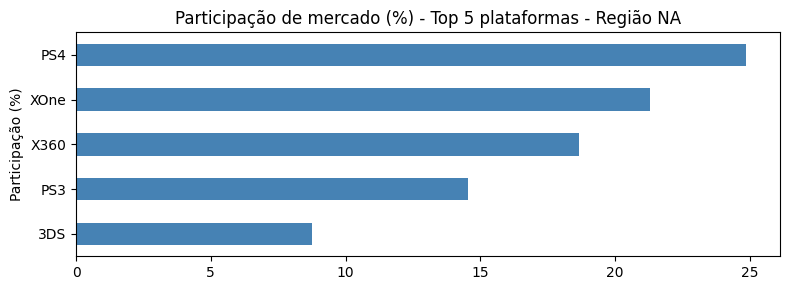

In [ ]:
# gráfico de barras com a participação de mercado das top 5 plataformas na região NA
top5_na = na_plat.head(5)

top5_na.plot(x='platform', y='participation_%', kind='barh',
             figsize=(8,3), legend=False, color='steelblue',
             title='Participação de mercado (%) - Top 5 plataformas - Região NA',
             xlabel='Participação (%)', ylabel='Plataforma')
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()


* as cinco principais plataformas da região NA podem ser vista no gráfico acima
* o somatório da participação destas 5 plataformas superam 85% do mercado na região.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v2 (César Malaguti):</b> <a class="tocSkip"></a>

**O perfil da América do Norte agora descreve o mercado de 2017.** PS4 (24,9%), XOne (21,3%), X360, PS3 e 3DS, somando 88% das vendas. É o top 5 que eu obtenho com o mesmo recorte, e PS4 e XOne, que estavam fora na v1, agora lideram.
</div>

<div class="alert alert-block alert-danger">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

**Este perfil ficou desatualizado por causa do período.** O top 5 da América do Norte é X360, PS2, Wii, PS3 e DS, e você mesmo escreveu que PS4 e XOne *"ainda não contemplam o cenário daquelas que mais participam do mercado na região até então"*. O "até então" é o sinal: o perfil descreve o passado. Com o recorte recente, o top 5 passa a ser PS4, XOne, X360, 3DS e PS3. O mesmo vale para a Europa e o Japão, e para os gêneros e o ESRB.
</div>

<div class="alert alert-block alert-info"><b>Resposta do aluno</b> <a class="tocSkip"></a> 
    
* Em função do novo recorte temporal os dados foram ajustados e contemplam a até então realidade
</div>

### Os cinco principais gêneros. 

#### Explique a diferença.

In [ ]:
# levantando dados sobre o faturamento em relação ao gênero na região
na_genre = (
    df.groupby('genre')['na_sales_milions'].sum().reset_index()
    .sort_values('na_sales_milions', ascending=False)
).reset_index(drop=True)

print(na_genre)


           genre  na_sales_milions
0         Action            125.83
1        Shooter            109.74
2         Sports             65.27
3   Role-Playing             46.40
4           Misc             27.46
5       Platform             17.93
6       Fighting             15.55
7         Racing             12.96
8      Adventure              7.14
9     Simulation              4.75
10      Strategy              3.28
11        Puzzle              0.83


In [ ]:
# obtendo o percentual de suas cotas de participação na região 
na_genre['participation_%'] = (na_genre['na_sales_milions'] / 
                               na_genre['na_sales_milions'].sum()*100).round(2)

print(na_genre)


           genre  na_sales_milions  participation_%
0         Action            125.83            28.78
1        Shooter            109.74            25.10
2         Sports             65.27            14.93
3   Role-Playing             46.40            10.61
4           Misc             27.46             6.28
5       Platform             17.93             4.10
6       Fighting             15.55             3.56
7         Racing             12.96             2.96
8      Adventure              7.14             1.63
9     Simulation              4.75             1.09
10      Strategy              3.28             0.75
11        Puzzle              0.83             0.19


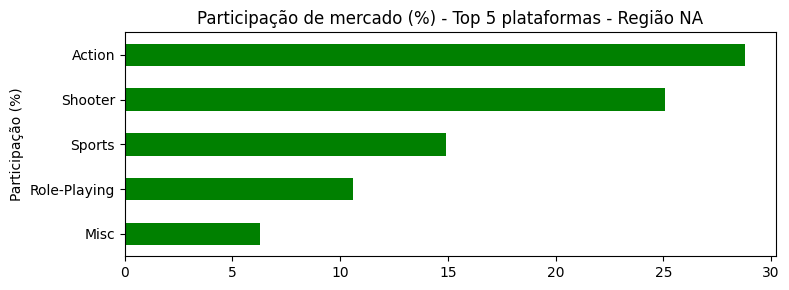

In [ ]:
# gráfico de barras com a participação de mercado das top 5 plataformas na região NA
top5_genre_na = na_genre.head(5)

top5_genre_na.plot(x='genre', y='participation_%', kind='barh',
             figsize=(8,3), legend=False, color='green',
             title='Participação de mercado (%) - Top 5 plataformas - Região NA',
             xlabel='Participação (%)', ylabel='Plataforma')
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()


* aproximadamente 70% do mercado nesta região é dominado pelos 5 principais gêneros
* para esta região os gêneros de ação e esporte também dominam o mercado. Como o gênero 'Shooter' e o 'Racing' ocupam o terceiro e quinto lugares respectivamente, é esperado que eles estejam associados à ação ou ao esporte.
* o gênero 'RPG (Role-Playing)' que no total geral de vendas por gênero ocupa o quarto lugar, não aparece nos cinco maiores desta região.

<div class="alert alert-block alert-warning">
<b>Comentário do revisor v2 (César Malaguti):</b> <a class="tocSkip"></a>

**Os textos dos gêneros ainda são do recorte antigo.** Os cálculos foram atualizados, mas as frases não, e hoje elas contradizem as tabelas logo acima. Os pontos que encontrei:

- **Total por gênero:** o texto diz que ação e esporte lideram, seguidos por tiro e RPG. A tabela mostra Action (321), **Shooter (233)**, Sports (151) e Role-Playing (146). O mesmo vale para a conclusão geral.
- **América do Norte:** o texto diz que Shooter é o terceiro e Racing o quinto, e que RPG não aparece no top 5. Na tabela, Shooter é o **segundo**, RPG é o **quarto** e Racing nem entra (o quinto é Misc). E os cinco gêneros somam **86%**, e não cerca de 70%.
- **Europa:** o mesmo caso. Shooter é o segundo, RPG é o quarto e está no top 5, e os cinco somam **83%**.
- **Japão:** o texto soma Role-Playing e Platform, mas Platform não está no top 5; o RPG sozinho já tem 36%. E 36% não é mais o dobro do segundo colocado (Action, 29%). Os cinco somam **82%**.
- **Plataformas do Japão:** o XOne é o **sucessor** do X360, e não o antecessor.

Uma forma de evitar isso daqui para frente: sempre que um texto citar uma posição ou um percentual, escreva o número direto da tabela, em vez de descrever de memória.
</div>

### As classificações do ESRB afetam as vendas

In [ ]:
# filtrando os dados sobre ESRB e as vendas na região
rating_na = (
    df[['na_sales_milions', 'rating', 'rating_code']].dropna(subset=['rating'])
)
print(rating_na)


      na_sales_milions rating  rating_code
0                 7.02      M            4
1                 9.66      M            4
4                 3.96      M            4
6                 6.73      M            4
7                 4.10      M            4
...                ...    ...          ...
2200              0.00      E            1
2204              0.00      E            1
2205              0.00   E10+            2
2211              0.01      M            4
2218              0.00      M            4

[1250 rows x 3 columns]


* conforme explicado na sessão correspondente, neste momento, os dados ausentes foram filtrados da coluna 'rating' para gerar informação relevante.
* é importante pontuar que ainda ficaram dados de classificação desatualizados, contudo está sendo considerado que é a classificação atual até então.

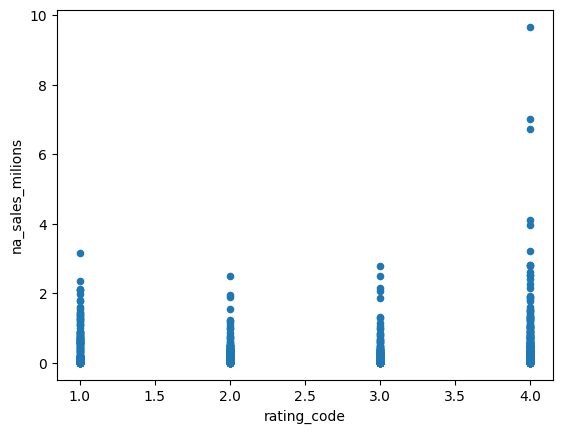

In [ ]:
# construir um gráfico de dispersão
rating_na.plot(x='rating_code',
            y='na_sales_milions',
            kind='scatter')

plt.show()


* gráfico de dispersão não foi elucidativo, então será calculada a correlação para buscar confirmações

In [ ]:
# cálculo da correlação entre o rating e as vendas na região
corr_rating_na=(
    rating_na['rating_code'].astype('int64')
    .corr(rating_na['na_sales_milions'])
)

print(f'Correlação entre classificação ESRB e vendas na região NA: {corr_rating_na:.2f}')

Correlação entre classificação ESRB e vendas na região NA: 0.10


* o gráfico de dispersão não foi elucidativo e o calculo da correlação apresentou valor muito baixo de correlação. Dessa forma, para esta questão, partiu-se par a abordagem de um novo gráfico de barras horizontal avaliando a porcentagem de participação do rating nas vendas totais da região (sem filtro)

In [ ]:
# levantando dados sobre ESRB e as vendas na região
esrb_na = (
    df.groupby('rating')['na_sales_milions'].sum().reset_index()
    .sort_values('na_sales_milions', ascending=False)
    .reset_index(drop=True)
)

print(esrb_na)


  rating  na_sales_milions
0      M            165.21
1      E             78.94
2   E10+             54.02
3      T             49.79


In [ ]:
# obtendo o percentual de suas cotas de participação na região 
esrb_na['participation_%'] = (
    esrb_na['na_sales_milions'] / df['na_sales_milions'].sum() * 100
).round(2)
print(esrb_na)


  rating  na_sales_milions  participation_%
0      M            165.21            37.79
1      E             78.94            18.06
2   E10+             54.02            12.36
3      T             49.79            11.39


* para o total da participação de mercado, foi levado em consideração o somatório das vendas na região incluindo aquelas que haviam dados ausentes na coluna 'rating'

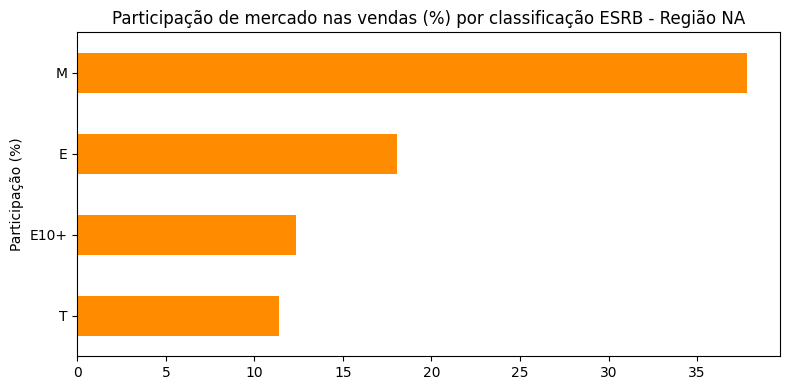

In [ ]:
# gráfico de barras com a participação das classificações ESRB na região
esrb_na.plot(x='rating', y='participation_%', kind='barh',
             figsize=(8,4), legend=False, color='darkorange',
             title='Participação de mercado nas vendas (%) por classificação ESRB - Região NA',
             xlabel='Participação (%)', ylabel='Classificação ESRB')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


* das vendas totais na região que tiveram a classificação ESRB é possível notar a prevalencia do público M (>17 anos) no volume de vendas.
* Desta forma, entende-se que a participação nas vendas da classificação nesta região se enquadra majoritariamente para um público M. 

## Região UE

### As cinco plataformas principais. 

#### Descreva as variações das suas quotas de mercado

In [ ]:
# levantando dados sobre o faturamento das plataformas na região
eu_plat = (
    df.groupby('platform')['eu_sales_milions'].sum().reset_index()
    .sort_values('eu_sales_milions', ascending=False)
)
eu_plat = eu_plat.reset_index(drop=True)
print(eu_plat.head(5))


  platform  eu_sales_milions
0      PS4            141.09
1      PS3             67.81
2     XOne             51.59
3     X360             42.52
4      3DS             30.96


In [ ]:
# obtendo o percentual de suas cotas de participação na região 
eu_plat['participation_%'] = (
    eu_plat['eu_sales_milions']/ eu_plat['eu_sales_milions'].sum()*100
).round(2)

print(eu_plat)


  platform  eu_sales_milions  participation_%
0      PS4            141.09            36.05
1      PS3             67.81            17.33
2     XOne             51.59            13.18
3     X360             42.52            10.86
4      3DS             30.96             7.91
5       PC             25.36             6.48
6     WiiU             19.85             5.07
7      PSV              6.10             1.56
8      Wii              5.93             1.52
9      PSP              0.17             0.04


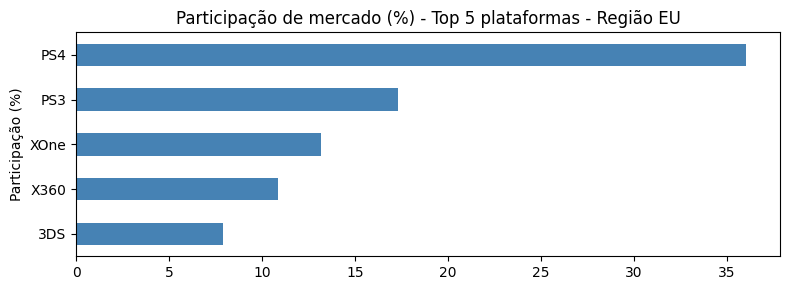

In [ ]:
# gráfico de barras com a participação de mercado das top 5 plataformas na região
top5_eu = eu_plat.head(5)

top5_eu.plot(x='platform', y='participation_%', kind='barh',
             figsize=(8,3), legend=False, color='steelblue',
             title='Participação de mercado (%) - Top 5 plataformas - Região EU',
             xlabel='Participação (%)', ylabel='Plataforma')
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()


* as cinco principais plataformas da região EU podem ser vista no gráfico acima
* o somatório da participação destas 5 plataformas somam quase 85% do mercado na região.


### Os cinco principais gêneros. 

#### Explique a diferença.

In [ ]:
# levantando dados sobre o faturamento em relação ao gênero na região
eu_genre = (
    df.groupby('genre')['eu_sales_milions'].sum().reset_index()
    .sort_values('eu_sales_milions', ascending=False)
).reset_index(drop=True)

print(eu_genre)


           genre  eu_sales_milions
0         Action            117.89
1        Shooter             87.86
2         Sports             60.49
3   Role-Playing             36.97
4         Racing             20.19
5           Misc             20.00
6       Platform             15.15
7     Simulation             10.84
8       Fighting              8.55
9      Adventure              8.22
10      Strategy              4.22
11        Puzzle              1.00


In [ ]:
# obtendo o percentual de suas cotas de participação na região 
eu_genre['participation_%'] = (
    eu_genre['eu_sales_milions'] / eu_genre['eu_sales_milions'].sum()*100
).round(2)

print(eu_genre)

           genre  eu_sales_milions  participation_%
0         Action            117.89            30.12
1        Shooter             87.86            22.45
2         Sports             60.49            15.46
3   Role-Playing             36.97             9.45
4         Racing             20.19             5.16
5           Misc             20.00             5.11
6       Platform             15.15             3.87
7     Simulation             10.84             2.77
8       Fighting              8.55             2.18
9      Adventure              8.22             2.10
10      Strategy              4.22             1.08
11        Puzzle              1.00             0.26


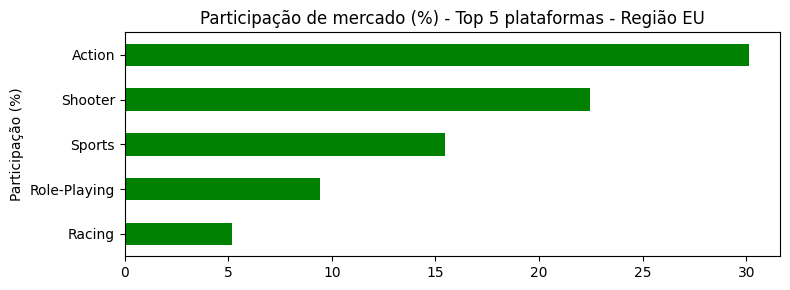

In [ ]:
# gráfico de barras com a participação de mercado das top 5 plataformas na região NA
top5_genre_eu = eu_genre.head(5)

top5_genre_eu.plot(x='genre', y='participation_%', kind='barh',
             figsize=(8,3), legend=False, color='green',
             title='Participação de mercado (%) - Top 5 plataformas - Região EU',
             xlabel='Participação (%)', ylabel='Plataforma')
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()


* aproximadamente 70% do mercado nesta região é dominado pelos 5 principais generos
* de forma análoga à região NA, para esta região os gêneros de ação e esporte também dominam o mercado. Como o gênero 'Shooter' e o 'Racing' ocupam o terceiro e quarto lugares respectivamente, é esperado que eles estejam associados à ação ou ao esporte.
* o gênero 'RPG (Role-Playing)' que no total geral de vendas por gênero ocupa o quarto lugar, também não aparece nos cinco maiores desta região.

### As classificações do ESRB afetam as vendas

In [ ]:
# levantando dados sobre ESRB e as vendas na região
esrb_eu = (
    df.groupby('rating')['eu_sales_milions'].sum().reset_index()
    .sort_values('eu_sales_milions', ascending=False)
    .reset_index(drop=True)
)

print(esrb_eu)


  rating  eu_sales_milions
0      M            145.32
1      E             82.97
2   E10+             42.53
3      T             41.95


* conforme explicado na sessão correspondente, neste momento, os dados ausentes foram filtrados da coluna 'rating' para gerar informação relevante.
* é importante pontuar que ainda ficaram dados de classificação desatualizados, contudo está sendo considerado que é a classificação atual até então.

In [ ]:
# obtendo o percentual de suas cotas de participação na região 
esrb_eu['participation_%'] = (
    esrb_eu['eu_sales_milions'] / df['eu_sales_milions'].sum() * 100
).round(2)

print(esrb_eu)


  rating  eu_sales_milions  participation_%
0      M            145.32            37.13
1      E             82.97            21.20
2   E10+             42.53            10.87
3      T             41.95            10.72


* para o total da participação de mercado, foi levado em consideração o somatório das vendas na região incluindo aquelas que haviam dados ausentes na coluna 'rating'

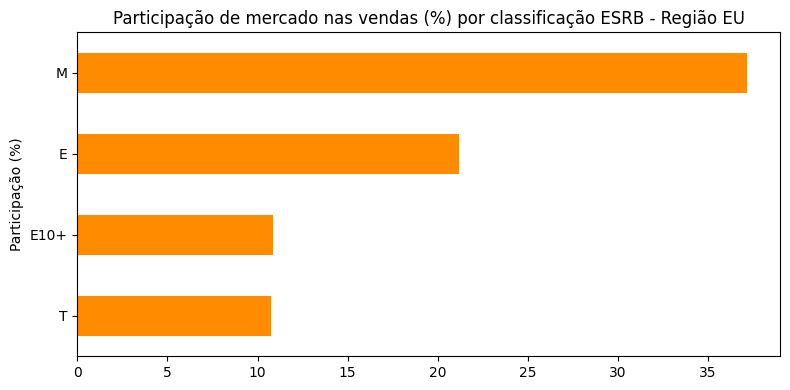

In [ ]:
# gráfico de barras com a participação das classificações ESRB na região
esrb_eu.plot(x='rating', y='participation_%', kind='barh',
             figsize=(8,4), legend=False, color='darkorange',
             title='Participação de mercado nas vendas (%) por classificação ESRB - Região EU',
             xlabel='Participação (%)', ylabel='Classificação ESRB')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


* das vendas totais na região que tiveram a classificação ESRB é possível notar a prevalencia do público M (>17 anos) no volume de vendas.
* Desta forma, entende-se que a participação nas vendas da classificação nesta região se enquadra majoritariamente para um público M.

## Região JP

### As cinco plataformas principais. 

### Descreva as variações das suas quotas de mercado

In [ ]:
# levantando dados sobre o faturamento das plataformas na região
jp_plat = (
    df.groupby('platform')['jp_sales_milions'].sum().reset_index()
    .sort_values('jp_sales_milions', ascending=False)
)
jp_plat = jp_plat.reset_index(drop=True)
print(jp_plat.head(5))


  platform  jp_sales_milions
0      3DS             67.81
1      PS3             23.35
2      PSV             18.59
3      PS4             15.96
4     WiiU             10.88


In [ ]:
# obtendo o percentual de suas cotas de participação na região 
jp_plat['participation_%'] = (
    jp_plat['jp_sales_milions'] / jp_plat['jp_sales_milions'].sum()*100
).round(2)

print(jp_plat)


  platform  jp_sales_milions  participation_%
0      3DS             67.81            48.17
1      PS3             23.35            16.59
2      PSV             18.59            13.21
3      PS4             15.96            11.34
4     WiiU             10.88             7.73
5      PSP              3.29             2.34
6     X360              0.51             0.36
7     XOne              0.34             0.24
8      Wii              0.05             0.04
9       PC              0.00             0.00


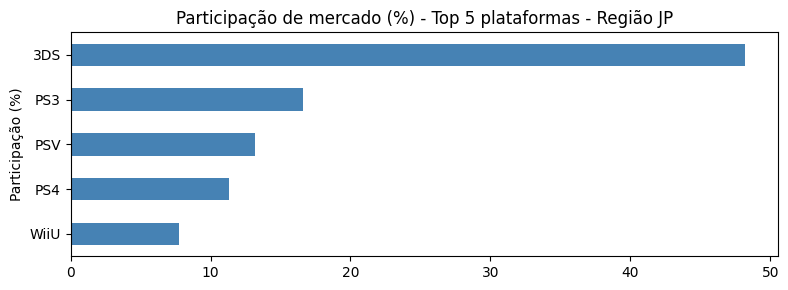

In [ ]:
# gráfico de barras com a participação de mercado das top 5 plataformas na região NA
top5_jp = jp_plat.head(5)

top5_jp.plot(x='platform', y='participation_%', kind='barh',
             figsize=(8,3), legend=False, color='steelblue',
             title='Participação de mercado (%) - Top 5 plataformas - Região JP',
             xlabel='Participação (%)', ylabel='Plataforma')
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()


* as cinco principais plataformas da região JP podem ser vista no gráfico acima
* o somatório da participação destas 5 plataformas somam mais de 97% do mercado na região.
* Apesar do PS4 e XOne serem as únicas plataformas com tendência de crescimento, nesta região é notado um comportamento diferente. Aparentemente, existe um tempo de latência maior aqui para a troca dos consoles. Os antecessores mais antigos tem uma fatia importante do mercado e o antecessor do X360 ( o XOne) nem aparece contemplado entre as 5 plataformas com maior venda neste mercado.
* este fato precisa ser estudado mais a fundo, tendo em vista que pode ser um comportamento tradicional nesta região ou um delay no lançamento de novos games e plataformas nesta região. Para qualquer que seja o motivo, será necessário compreende-lo para se posicionar melhor de forma estratégica.


<div class="alert alert-block alert-success">
<b>Comentário do revisor v2 (César Malaguti):</b> <a class="tocSkip"></a>

**A leitura do Japão é a mais interessante do perfil regional.** O 3DS tem 48% do mercado japonês, e o XOne, que é o segundo da América do Norte, tem só 0,24%. Você percebeu que o Japão não segue a tendência global e, em vez de forçar uma explicação, deixou duas hipóteses para investigar. Para a loja, isso vira uma decisão concreta: a campanha no Japão tem que ser pensada à parte.
</div>

### Os cinco principais gêneros. 

#### Explique a diferença.

In [ ]:
# levantando dados sobre o faturamento em relação ao gênero na região
jp_genre = (
    df.groupby('genre')['jp_sales_milions'].sum().reset_index()
    .sort_values('jp_sales_milions', ascending=False)
).reset_index(drop=True)

print(jp_genre)


           genre  jp_sales_milions
0   Role-Playing             51.04
1         Action             40.49
2           Misc              9.20
3       Fighting              7.65
4        Shooter              6.61
5      Adventure              5.82
6         Sports              5.41
7       Platform              4.79
8     Simulation              4.52
9         Racing              2.30
10      Strategy              1.77
11        Puzzle              1.18


In [ ]:
# obtendo o percentual de suas cotas de participação na região 
jp_genre['participation_%'] = (
    jp_genre['jp_sales_milions'] / jp_genre['jp_sales_milions'].sum()*100
).round(2)

print(jp_genre)

           genre  jp_sales_milions  participation_%
0   Role-Playing             51.04            36.26
1         Action             40.49            28.76
2           Misc              9.20             6.54
3       Fighting              7.65             5.43
4        Shooter              6.61             4.70
5      Adventure              5.82             4.13
6         Sports              5.41             3.84
7       Platform              4.79             3.40
8     Simulation              4.52             3.21
9         Racing              2.30             1.63
10      Strategy              1.77             1.26
11        Puzzle              1.18             0.84


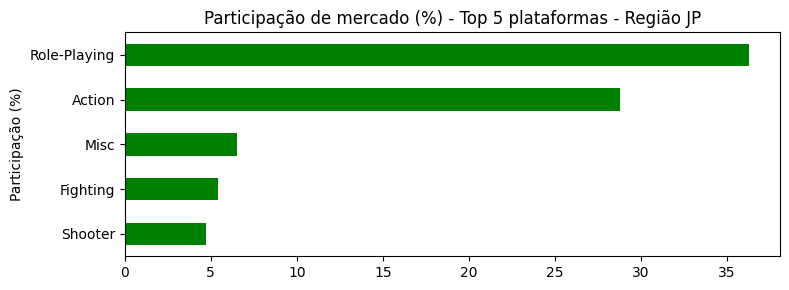

In [ ]:
# gráfico de barras com a participação de mercado das top 5 plataformas na região NA
top5_genre_jp = jp_genre.head(5)

top5_genre_jp.plot(x='genre', y='participation_%', kind='barh',
             figsize=(8,3), legend=False, color='green',
             title='Participação de mercado (%) - Top 5 plataformas - Região JP',
             xlabel='Participação (%)', ylabel='Plataforma')
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()


* aproximadamente 70% do mercado nesta região é dominado pelos 5 principais generos
* esta região, contudo, apresenta uma seleção de gênero muito distinta das demais
* ainda existe a participação dos jogos de ação e esporte, contudo, a fatia de mercado consumida por 'Role-Playing' e 'Platform' somados ultrapassam 35% do mercado
* em especial o gênero 'Role-Playing' assume uma margem de consumo que é mais que o doblo do segundo colocado
* este fenômeno pode ajudar a explicar a manutenção dos consoles mais antigos tendo em vista que este tipo de jogo não é tão imediatista. Ele requer mais tempo de acompanhamento para o desenrolar da história e deve acompanhar o crescimento do usuário por mais tempo, gerando fidelização maior.
* o grande volume de consumo deste gênero reflete no total global, como o 'Role-Playing' ficando em quarto lugar.

### As classificações do ESRB afetam as vendas

In [ ]:
# levantando dados sobre ESRB e as vendas na região
esrb_jp = (
    df.groupby('rating')['jp_sales_milions'].sum().reset_index()
    .sort_values('jp_sales_milions', ascending=False)
    .reset_index(drop=True)
)

print(esrb_jp)


  rating  jp_sales_milions
0      T             20.59
1      E             15.14
2      M             14.11
3   E10+              5.89


* conforme explicado na sessão correspondente, neste momento, os dados ausentes foram filtrados da coluna 'rating' para gerar informação relevante.
* é importante pontuar que ainda ficaram dados de classificação desatualizados, contudo está sendo considerado que é a classificação atual até então.

In [ ]:
# obtendo o percentual de suas cotas de participação na região 
esrb_jp['participation_%'] = (
    esrb_jp['jp_sales_milions'] / df['jp_sales_milions'].sum() * 100
).round(2)

print(esrb_jp)


  rating  jp_sales_milions  participation_%
0      T             20.59            14.63
1      E             15.14            10.75
2      M             14.11            10.02
3   E10+              5.89             4.18


* para o total da participação de mercado, foi levado em consideração o somatório das vendas na região incluindo aquelas que haviam dados ausentes na coluna 'rating'

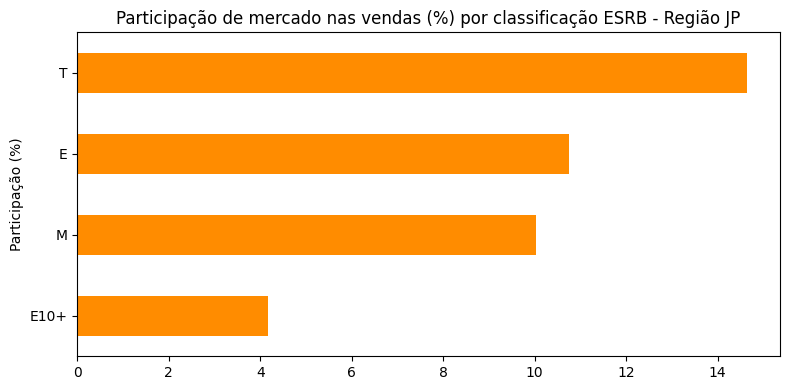

In [ ]:
# gráfico de barras com a participação das classificações ESRB na região
esrb_jp.plot(x='rating', y='participation_%', kind='barh',
             figsize=(8,4), legend=False, color='darkorange',
             title='Participação de mercado nas vendas (%) por classificação ESRB - Região JP',
             xlabel='Participação (%)', ylabel='Classificação ESRB')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


* diferente das outras regiões, a participação do público T (>13 anos) é maior no volume de vendas e a distribuição por classificação ESRB é mais homogênea.  
* Desta forma, diferentemente das outras regiões, entende-se que a participação nas vendas da classificação nesta região se enquadra mais fortemente para um público mais jovem T, no entanto as vendas são mais bem distribuidas para os outros públicos. Essa diferença deve ser notada como um nincho diferente de mercado.

# Testando as hipóteses

#### Qual o nível de significância que você escolheu para testar as hipóteses, e por quê.

* para os dois casos, o valor da significância (alpha) será 0,05
* o valor de significância de 0,05 é um padrão convencionado para análise exploratória de dados e negócios. Isto balancea o risco de falso positivo contra o comportamento excessivamente conservador.
* adicionamente, não há um motivo específica aqui (saúde ou uma de questão de segurança) para estabelecer uma significância tão restritiva quanto 0,01.

In [ ]:
##### Parâmetros
alpha = 0.05


## As classificações médias dos usuários das plataformas Xbox One e PC são as mesmas.

##### Hipóteses

* $H_0$ = as classificações médias dos usuários de Xbox One e PC são iguais.
* $H_1$ = as classificações médias dos usuários de Xbox One e PC são diferente.


* para um t-test a hipótese nula $H_0$ é sempre a declaração de similaridade (os eventos não causam mudanças), e a hipótese alternativa $H_1$ representa aquilo que está se buscado evicência para comprovar.

* será um teste bicaldal, uma vez que a questão é apenas descobrir se as médias são a mesmas ou não, não especificando a direção.

In [ ]:
# preparando os dados: user_score por plataforma, removendo valores ausentes
xone_scores = df[df['platform'] == 'XOne']['user_score_max10'].dropna()
pc_scores = df[df['platform'] == 'PC']['user_score_max10'].dropna()


In [ ]:
# avaliando as amostras estudadas
print('Xbox One:', len(xone_scores), 
      'linhas e variância de:', np.var(xone_scores).round(2))

print('PC:', len(pc_scores), 
      'linhas e variância de:', np.var(pc_scores).round(2))


Xbox One: 182 linhas e variância de: 1.9
PC: 155 linhas e variância de: 3.02


* equal_var deverá ser considerado False tendo em vista que as amostras têm tamanhos e variância diferentes.
* utilizar esta variável como True tornaria a suposição ainda mais frágil.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

**O teste está bem montado:** α justificado pelo contexto, teste bicaudal explicado, variâncias e tamanhos impressos antes de decidir o `equal_var`, e o teste de Welch pelo motivo certo. O método está correto; o que muda a conclusão é o recorte dos dados.
</div>

In [ ]:
# teste t de Welch (não assume variâncias iguais entre os dois grupos)
results_platform = st.ttest_ind(xone_scores, pc_scores, equal_var=False)

print('p-valor:', results_platform.pvalue)

if results_platform.pvalue < alpha:
    print('Rejeitamos a hipótese nula: as classificações médias são diferentes')
else:
    print('Não rejeitamos a hipótese nula: não há evidência suficiente de diferença nas classificações médias')


p-valor: 0.14759594013430463
Não rejeitamos a hipótese nula: não há evidência suficiente de diferença nas classificações médias


* considerando que o p-valor (0,15) ficou muito superior ao alpha estabelecido (0,05), a hipótese nula de que as classificações médias dos usuários de Xbox One e PC são iguais não pode ser é rejeitada.
* Desta forma, deve-se considerar que não há evidências suficiente de diferença nas classificações médias dos usuários de Xbox One e PC são diferentes.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v2 (César Malaguti):</b> <a class="tocSkip"></a>

**Agora a conclusão está certa.** Com o recorte de 2013, p = 0,148, e a hipótese nula não é rejeitada: não há evidência de diferença entre as notas médias dos usuários de XOne e PC. É o mesmo valor que obtive ao refazer o teste. E a comparação ficou justa, porque agora os jogos de PC são do mesmo período em que o XOne existe.
</div>

<div class="alert alert-block alert-danger">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

**Com o período recente, esta conclusão se inverte.** Refiz o teste a partir de 2013: p = 0,15, e a hipótese nula **não é rejeitada**. A partir de 2014, p = 0,12. O Xbox One só existe desde 2013, então a comparação só é justa com os jogos de PC do mesmo período.
</div>

<div class="alert alert-block alert-info"><b>Resposta do aluno</b> <a class="tocSkip"></a> 
    
* em função do novo recorte temporal os resultados se ajustaram automaticamente e a conclusão foi re-escrita
</div>

## As classificações médias de usuários para os gêneros Action (ação) e Sports (esportes) são diferentes.

##### Hipóteses

* $H_0$ = as classificações médias dos usuários dos gêneros Action e Sports são iguais
* $H_1$ = as classificações médias dos usuários dos gêneros Action e Sports são diferentes

* para um t-test a hipótese nula $H_0$ é sempre a declaração de similaridade (os eventos não causam mudanças), e a hipótese alternativa $H_1$ representa aquilo que está se buscado evicência para comprovar.

* será um teste bicaldal, uma vez que a questão é apenas descobrir se as médias são a mesmas ou não, não especificando a direção.

In [ ]:
# preparando os dados: user_score por gênero, removendo valores ausentes
action_scores = df[df['genre'] == 'Action']['user_score_max10'].dropna()
sports_scores = df[df['genre'] == 'Sports']['user_score_max10'].dropna()


In [ ]:
# avaliando as amostras estudadas
print('Action:', len(action_scores), 
      'linhas e variância de:', np.var(action_scores).round(2))

print('Sports:', len(sports_scores), 
      'linhas e variância de:', np.var(sports_scores).round(2))


Action: 388 linhas e variância de: 1.76
Sports: 160 linhas e variância de: 3.16


* equal_var deverá ser considerado False tendo em vista que as amostras têm tamanhos e variância diferentes.
* utilizar esta variável como True tornaria a suposição ainda mais frágil.

In [ ]:
# teste t de Welch
results_genre = st.ttest_ind(action_scores, sports_scores, equal_var=False)

print('p-valor:', results_genre.pvalue)

if results_genre.pvalue < alpha:
    print('Rejeitamos a hipótese nula: as classificações médias são diferentes')
else:
    print('Não rejeitamos a hipótese nula: não há evidência suficiente de diferença nas classificações médias')

p-valor: 1.1330204667098058e-20
Rejeitamos a hipótese nula: as classificações médias são diferentes


* considerando que o p-valor (1e-20) ficou muito inferior ao alpha estabelecido (0,05), a hipótese nula  de que as médias dos usuários dos gêneros Action e Sports são iguais é rejeitada.
* Desta forma, deve-se considerar que as classificações médias dos usuários dos gêneros Action e Sports são diferentes.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v2 (César Malaguti):</b> <a class="tocSkip"></a>

**E esta também.** p ≈ 1e-20, a hipótese nula é rejeitada: nos jogos recentes, as notas médias de Action e Sports são diferentes. A pequena diferença para o meu valor vem da forma como cada um preencheu os anos ausentes, e não muda nada na conclusão.
</div>

<div class="alert alert-block alert-danger">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

**Esta também se inverte.** A partir de 2013, o teste entre Action e Sports dá p ≈ 1e-20, e a hipótese nula é **rejeitada**: as notas médias dos dois gêneros são diferentes nos jogos recentes.
</div>

<div class="alert alert-block alert-info"><b>Resposta do aluno</b> <a class="tocSkip"></a> 
    
* em função do novo recorte temporal os resultados se ajustaram automaticamente e a conclusão foi re-escrita
</div>

# Conclusão geral

* Sobre os dados: o dataset original continha vendas de jogos de 1980 a 2016. Após o tratamento de dados ausentes e duplicados, o período de análise foi restrito a 2013–2016 (considerando o plato de vendas do período mais moderno), e apenas plataformas com faturamento relevante (acima de 1% do maior faturamento) foram mantidas.
* Ciclo de vida das plataformas: o tempo de vida de uma plataforma varia de 3 a 31 anos, com média de aproximadamente 11 anos, refletindo um padrão claro de sucessão geracional.
* Plataformas líderes e potencialmente lucrativas: no período de 2013–2016, apenas PS4 e XOne apresentaram tendência de crescimentotornando-as as apostas mais lucrativas para o próximo ciclo. As top 5 foram PS4, PS3, XOne, 3DS, X360.
* Distribuição das vendas por plataforma: forte assimetria à direita em todas as plataformas (mediana geralmente abaixo de 0,5 milhão de cópias), confirmada estatisticamente pelo teste de Kruskal-Wallis (p ≈ 0,0000). A mediana, não a média, é a métrica mais confiável.
* Avaliações e vendas (PS3): correlação muito fraca com avaliações de usuários (≈ 0,00) e moderada com avaliações da crítica (≈ 0,33) — a crítica profissional pesa mais na decisão de compra.
* Mesmo jogo, plataformas diferentes: o mesmo título pode performar de forma muito distinta conforme a plataforma (ex.: FIFA 14/15 ilustra a transição PS3 → PS4.).
* Gêneros mais lucrativos: Ação e Esportes lideram, seguidos por Shooter e RPG — impedindo uma generalização simplista sobre "ação = vendas", o perfil regional tem muita influência nesta questão.
* Perfis regionais:NA e EU parecidos (PS4/XOne/X360 líderes, Action/Shooter dominam gêneros, público M lidera ESRB — inversão em relação ao recorte anterior, onde E liderava). JP muito mais concentrado (3DS com 48%!), RPG domina gêneros, público T lidera ESRB — perfil distinto que pede estratégia própria.
* Testes de hipóteses: não se rejeita H₀ para Xbox One vs. PC (p ≈ 0,15) — sem evidência suficiente de diferença; rejeita-se H₀ para Action vs. Sports (p ≈ 1e-20) — classificações diferentes.
* Recomendação estratégica: priorizar PS4/XOne, focar em Ação/Shooter/Sports/RPG por região, valorizar a crítica profissional no marketing, e manter o recorte temporal sempre alinhado ao horizonte de decisão do negócio.